In [1]:
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc
from scanpy import AnnData
sc.set_figure_params(figsize=(4,4))
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype']=42
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scanpy import AnnData

In [2]:
adata=sc.read_h5ad('mmDPT_allMGE.h5ad')

In [3]:
meta=pd.read_csv('../../REVISION/metadata_passQC_05212026.tsv.gz',sep='\t').set_index('ID')
for c in meta.columns:
    adata.obs[c]=meta[c]

In [4]:
dpt=adata.obs

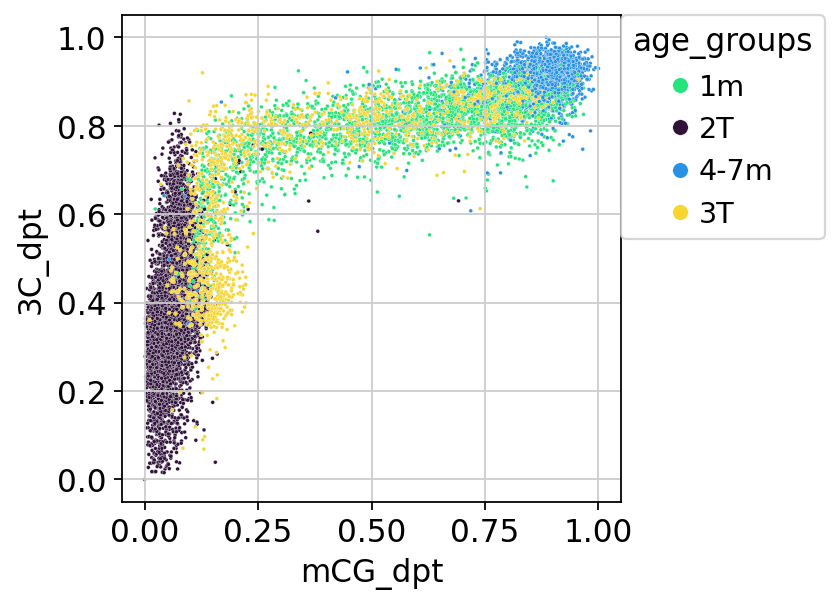

In [5]:
ax=sns.scatterplot(data=dpt,x='mCG_dpt',y='3C_dpt',hue='age_groups',
               palette=['#27e37b','#30123b','#2a92e5','#f6d531','#aa40fc'],
                   s=3)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1),borderaxespad=0.,markerscale=4)
plt.savefig('mmDPT_MGEcross.pdf')

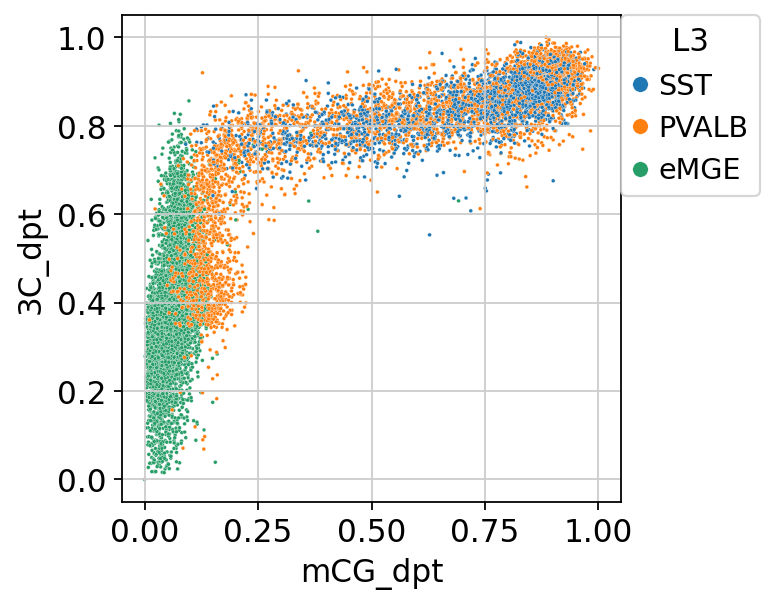

In [6]:
ax=sns.scatterplot(data=dpt,x='mCG_dpt',y='3C_dpt',hue='L3',
                   s=3)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1),borderaxespad=0.,markerscale=4)

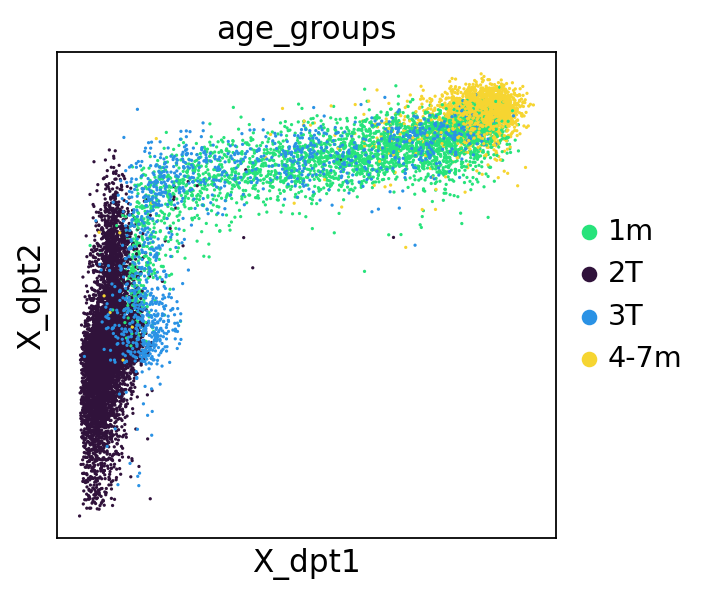

In [7]:
adata.obsm['X_dpt']=adata.obs[['mCG_dpt','3C_dpt']].values
sc.pl.embedding(adata,basis='X_dpt',color=['age_groups'],palette=['#27e37b','#30123b','#2a92e5','#f6d531','#aa40fc']
                ,save='MGE_mmDPTs.pdf',vmin=-1)

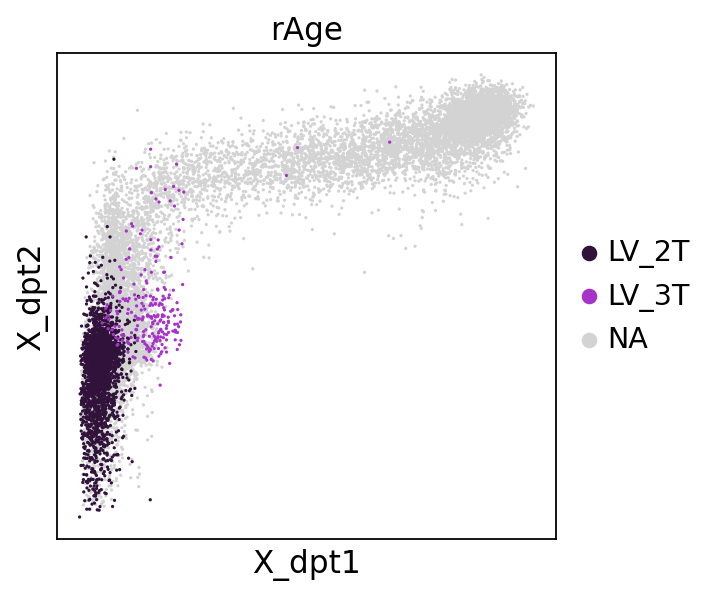

In [8]:
adata.obs['merge_region']=meta['region']
adata.obs['tr']=adata.obs['merge_region']
for i in adata.obs['tr'].unique():
    if i!='LV':
        adata.obs['tr']=adata.obs['tr'].replace(i,'')
    else:
        adata.obs['tr']=adata.obs['tr'].replace(i,'LV_')
adata.obs['rAge']=adata.obs['tr'].astype(str)+''+adata.obs['fine_age_groups'].astype(str)
adata.obs['rAge'].value_counts()
sc.pl.embedding(adata,basis='X_dpt',color=['rAge'],palette=['#27e37b','#aa40fc','#2a92e5','#f6d531','#30123b','#a734c9']
                ,save='MGE_mmDPTs_rAge.pdf',vmin=-1,groups=['LV_2T','LV_3T'])

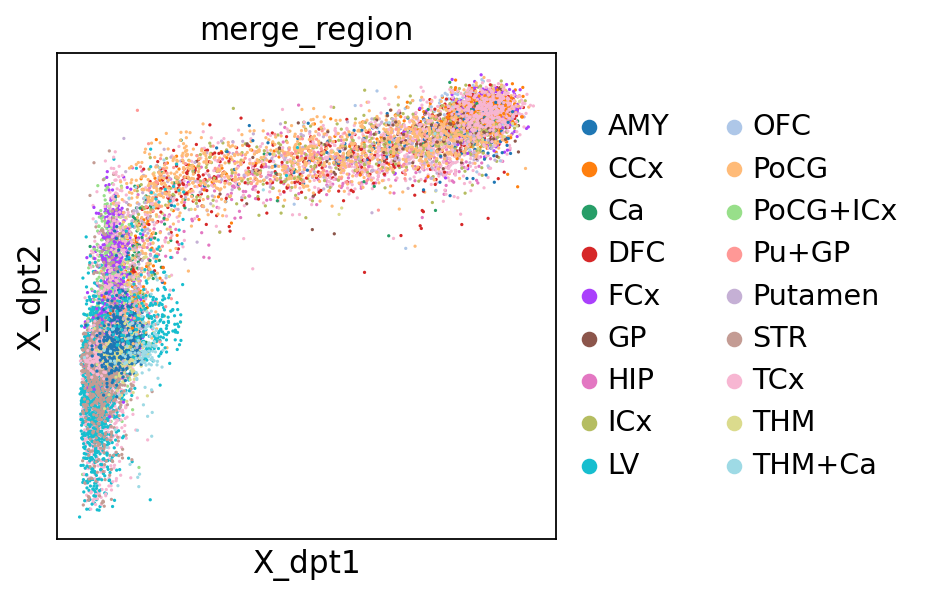

In [9]:
adata.obsm['X_dpt']=adata.obs[['mCG_dpt','3C_dpt']].values
sc.pl.embedding(adata,basis='X_dpt',color=['merge_region'] #,palette=['#27e37b','#30123b','#2a92e5','#f6d531','#aa40fc']
               )#,save='MGE_mmDPTs.pdf',vmin=-1)

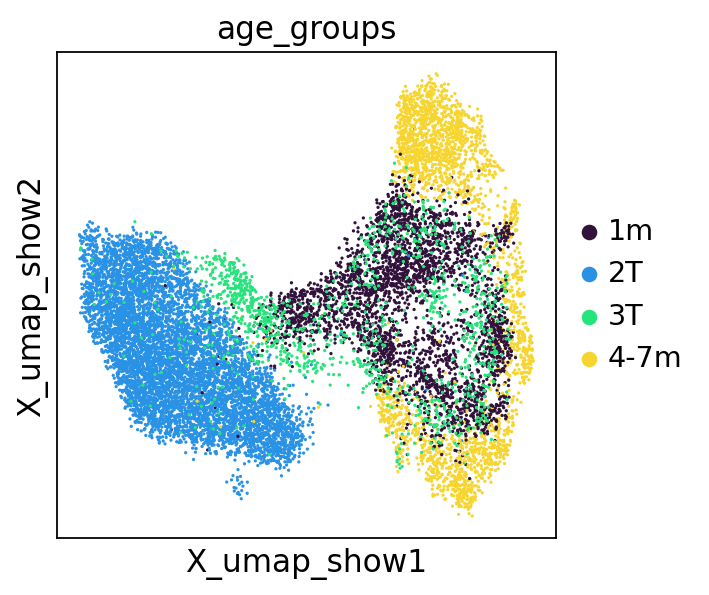

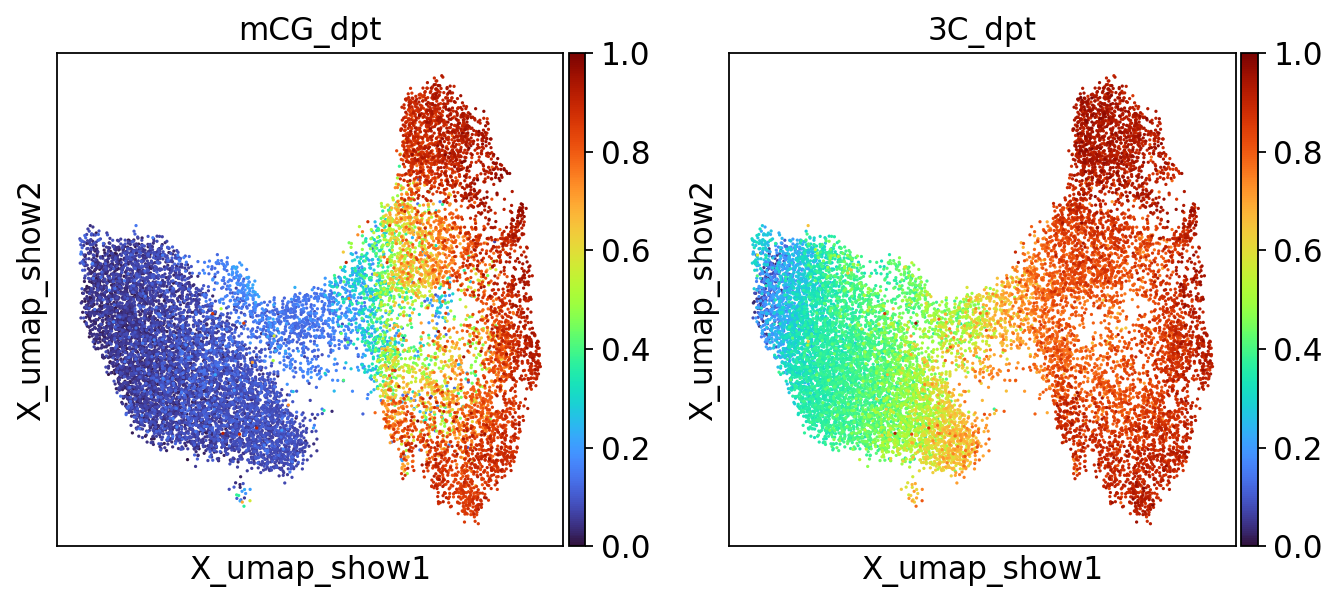

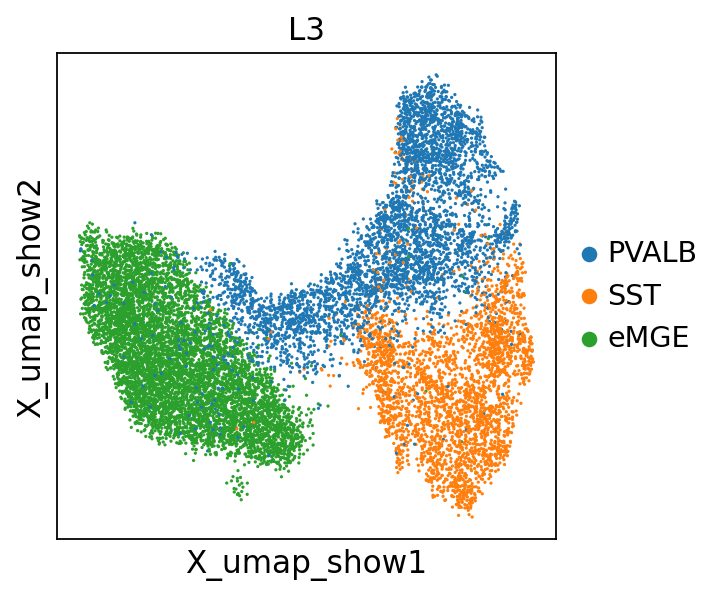

In [10]:
df=meta[meta['Case']=='4285']
sc.pl.embedding(adata,basis='X_umap_show',color=['age_groups'],palette=['#30123b','#2a92e5','#27e37b','#f6d531','#7a0403'])
sc.pl.embedding(adata,basis='X_umap_show',color=['mCG_dpt','3C_dpt'],cmap='turbo')
sc.pl.embedding(adata,basis='X_umap_show',color=['L3'],cmap='turbo',palette=sc.pl.palettes.vega_10)

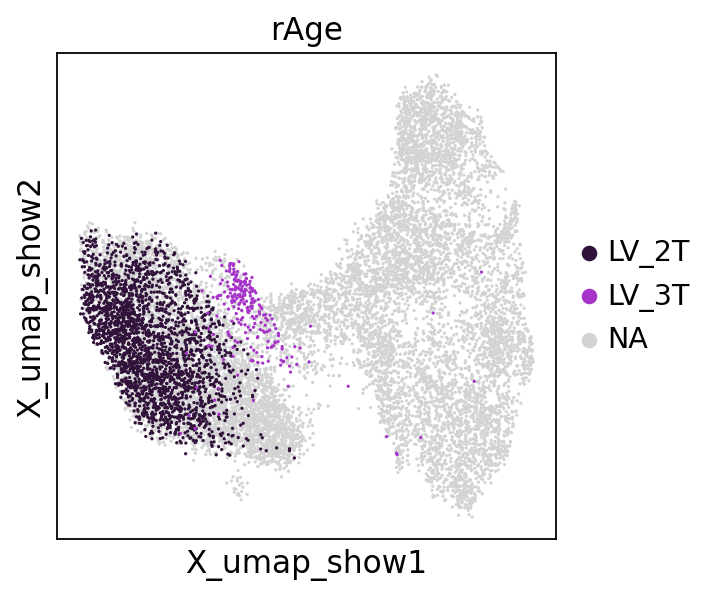

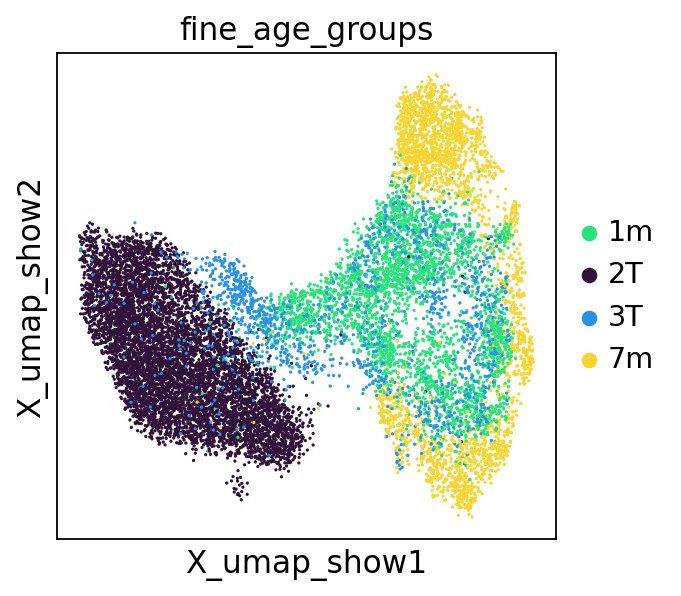

In [11]:
sc.pl.embedding(adata,basis='X_umap_show',color=['rAge'],palette=['#27e37b','#aa40fc','#2a92e5','#f6d531','#30123b','#a734c9']
                ,save='MGE_mmDPTs_rAge.pdf',vmin=-1,groups=['LV_2T','LV_3T'])
sc.pl.embedding(adata,basis='X_umap_show',color=['fine_age_groups'],palette=['#27e37b','#30123b','#2a92e5','#f6d531','#7a0403']
                ,save='MGE_mmDPTs_allAge.pdf',vmin=-1)

In [12]:
pdf=adata.obs[['3C_dpt','mCG_dpt','age_groups','L3','region']]
pdf['avg_dpt']=(pdf['3C_dpt']+pdf['mCG_dpt'])/2
pdf_2T=pdf[pdf['age_groups'].isin(['2T'])]
pdf_2T['age_groups']=pdf_2T['age_groups'].astype(str)

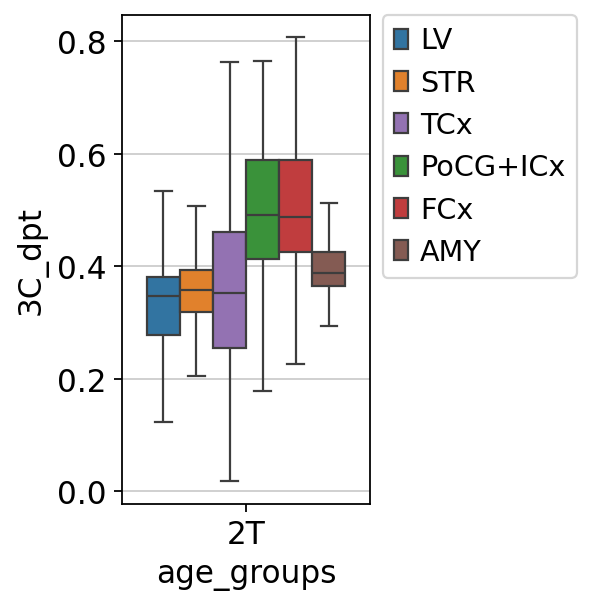

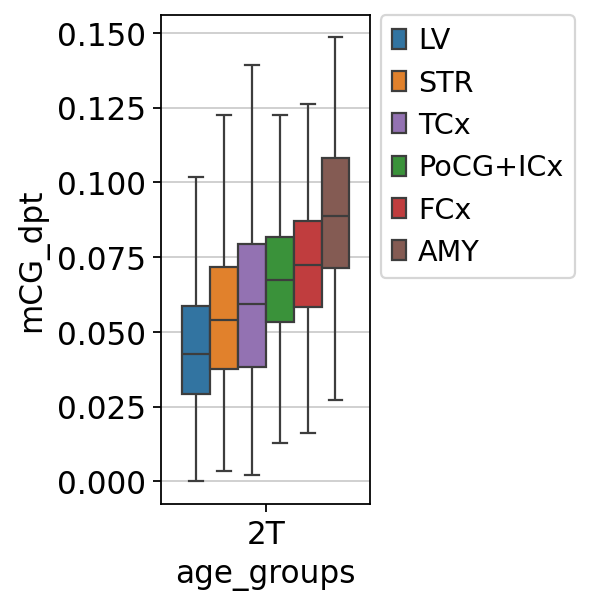

In [13]:
regs=pd.DataFrame(pdf_2T['region'].value_counts())
regs=regs[regs['count']>=50].index
regs=['LV', 'STR', 'FCx', 'TCx', 'AMY', 'PoCG+ICx']
sorted_regs=pdf_2T[pdf_2T['region'].isin(regs)][['region','mCG_dpt']].groupby('region').median().sort_values('mCG_dpt')
sorted_regs=sorted_regs[sorted_regs['mCG_dpt']>0]
plt.rcParams['figure.figsize']=(4,4)
sns.boxplot(data=pdf_2T, x="age_groups", y="3C_dpt", hue="region",
           hue_order=sorted_regs.index,showfliers=False,palette=['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.ylim(.4,.8)
plt.tight_layout()
plt.savefig('MGE_2T_3C_dpt_reg.pdf')
plt.show()
sns.boxplot(data=pdf_2T, x="age_groups", y="mCG_dpt", hue="region",
           hue_order=sorted_regs.index,showfliers=False,palette=['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.ylim(.4,.8)
plt.tight_layout()
plt.savefig('MGE_2T_mCG_dpt_reg.pdf')
plt.show()

In [14]:
from scipy import stats
group_a=pdf_2T[pdf_2T['region']=='LV']['mCG_dpt']
group_b=pdf_2T[~pdf_2T['region'].isin(['LV','THM'])]['mCG_dpt']
statistic, pvalue = stats.mannwhitneyu(
    group_a,
    group_b,
    alternative='two-sided'
)
print(statistic,pvalue)
group_a=pdf_2T[pdf_2T['region']=='LV']['3C_dpt']
group_b=pdf_2T[~pdf_2T['region'].isin(['LV','THM'])]['3C_dpt']
statistic, pvalue = stats.mannwhitneyu(
    group_a,
    group_b,
    alternative='two-sided'
)
print(statistic,pvalue)

2861830.0 8.823648929036937e-184
3097376.0 3.163702671857197e-146


In [15]:
import numpy as np
from scipy import stats

def median_fold_change_and_test(df, region_col, value_col, target_region='LV'):
    group_a = df[df[region_col] == target_region][value_col]      # LV
    group_b = df[df[region_col] != target_region][value_col]     # non-LV
    
    median_a = np.median(group_a)
    median_b = np.median(group_b)

    if median_b == 0:
        fold_change = np.inf if median_a > 0 else -np.inf
    else:
        fold_change = median_a / median_b

    statistic, pvalue = stats.mannwhitneyu(
        group_a,
        group_b,
        alternative='two-sided'
    )
    
    return fold_change, pvalue
pdf_2T=pdf_2T[pdf_2T['region']!='THM']
# mCG
fc_mcg, p_mcg = median_fold_change_and_test(pdf_2T, 'region', 'mCG_dpt')
print(f"mCG: median fold change (LV / non-LV) = {fc_mcg:.3f}")
print(p_mcg)

# 3C
fc_3c, p_3c = median_fold_change_and_test(pdf_2T, 'region', '3C_dpt')
print(f"3C: median fold change (LV / non-LV) = {fc_3c:.3f}")
print(p_3c)

mCG: median fold change (LV / non-LV) = 0.660
8.823648929036937e-184
3C: median fold change (LV / non-LV) = 0.889
3.163702671857197e-146


In [16]:
df=meta[meta['region']=='LV']
df=df[df['age_groups']=='3T']
df['Case'].value_counts()

Case
UMB4267    2255
Name: count, dtype: int64

In [17]:
df=meta[meta['region']=='LV']
df=df[df['age_groups']=='2T']
df['Case'].value_counts()

Case
UCSF2301    5309
Name: count, dtype: int64

In [18]:
palette=['#ff7f0e', '#2ca02c','#1f77b4',  '#d62728', '#8c564b', '#9467bd', '#e377c2',]

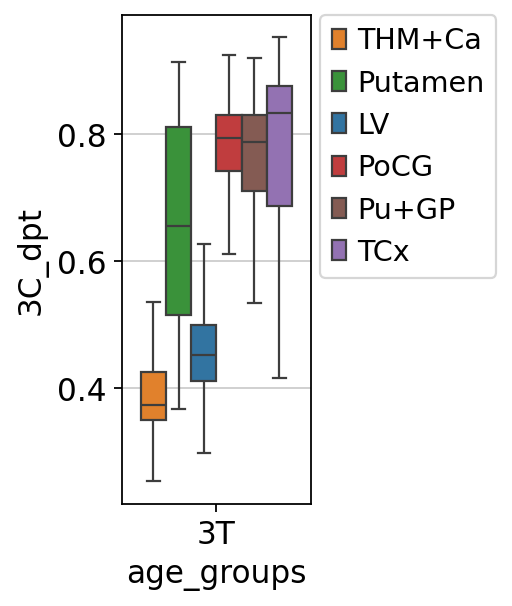

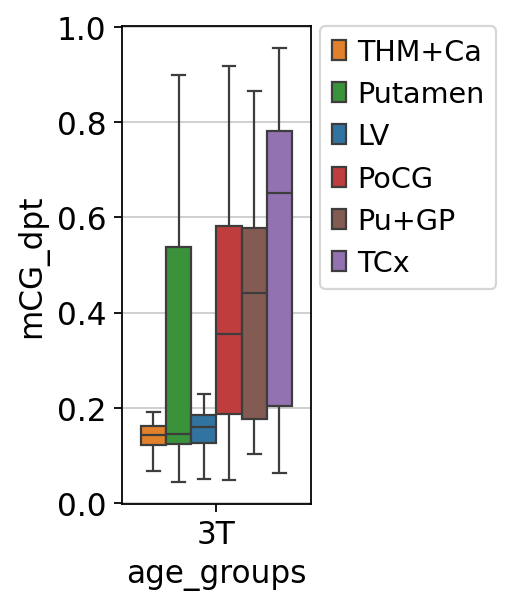

In [19]:
pdf_3T=pdf[pdf['age_groups'].isin(['3T'])]
pdf_3T['age_groups']=pdf_3T['age_groups'].astype(str)
regs=pd.DataFrame(pdf_3T['region'].value_counts())
regs=regs[regs['count']>=50].index
sorted_regs=pdf_3T[pdf_3T['region'].isin(regs)][['region','mCG_dpt']].groupby('region').median().sort_values('mCG_dpt')
sorted_regs=sorted_regs[sorted_regs['mCG_dpt']>0]
plt.rcParams['figure.figsize']=(3.5,4)
sns.boxplot(data=pdf_3T, x="age_groups", y="3C_dpt", hue="region",palette=palette,
           hue_order=sorted_regs.index,showfliers=False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.ylim(.4,.8)
plt.tight_layout()
plt.savefig('3T_reg_MGE_3C.pdf')
plt.show()
sns.boxplot(data=pdf_3T, x="age_groups", y="mCG_dpt", hue="region",palette=palette,
           hue_order=sorted_regs.index,showfliers=False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.ylim(.4,.8)
plt.tight_layout()
plt.savefig('3T_reg_MGE_mCG.pdf')
plt.show()

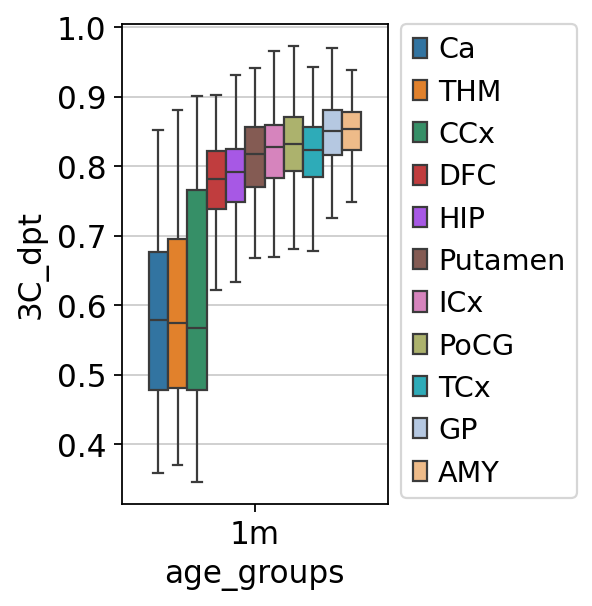

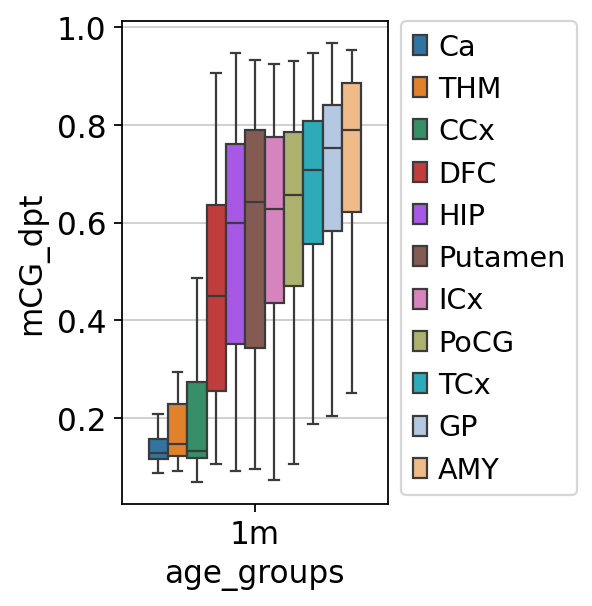

In [20]:
pdf_3T=pdf[pdf['age_groups'].isin(['1m'])]
pdf_3T['age_groups']=pdf_3T['age_groups'].astype(str)
regs=pd.DataFrame(pdf_3T['region'].value_counts())
regs=regs[regs['count']>=50].index
sorted_regs=pdf_3T[pdf_3T['region'].isin(regs)][['region','mCG_dpt']].groupby('region').mean().sort_values('mCG_dpt')
sorted_regs=sorted_regs[sorted_regs['mCG_dpt']>0]
plt.rcParams['figure.figsize']=(4,4)
sns.boxplot(data=pdf_3T, x="age_groups", y="3C_dpt", hue="region",
           hue_order=sorted_regs.index,showfliers=False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.ylim(.4,.8)
plt.tight_layout()
plt.show()
sns.boxplot(data=pdf_3T, x="age_groups", y="mCG_dpt", hue="region",
           hue_order=sorted_regs.index,showfliers=False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.ylim(.4,.8)
plt.tight_layout()
plt.show()